# 1. Maneuvering derivatives from potential flow: theory and verification

This is the first of three notebooks documenting the maneuvering-derivative
capability added to MarineHydro.jl. It states the boundary-value problem, the
discretization, and the force extraction, and then verifies each of them
against results that do not come from the solver.

| Notebook | Contents |
|---|---|
| **1. Theory and verification** (this one) | Governing equations, double-body construction, Wang extraction, analytical ellipsoid verification, and an exact ideal-flow check of the velocity derivatives |
| 2. KVLCC2 viscous correction | Gothenburg 2010 geometry, surface streamlines, Head's integral boundary layer, friction-drag validation, corrected derivatives |
| 3. Public-hull comparison | KCS, KVLCC2, DTMB 5415, DTC and Wigley derivatives and added masses against published references |

## What was added to MarineHydro

The base package solves the *radiation and diffraction* problem: a body
oscillating at frequency $\omega$ in waves. Maneuvering needs the opposite
limit — a body moving steadily at forward speed $U$ with slow lateral drift
and yaw. The new modules are

| File | Purpose |
|---|---|
| `src/maneuvering.jl` | Zero-frequency rigid-body potentials and the linear sway–yaw derivative integrals |
| `src/boundary_layers.jl` | Head's turbulent integral boundary layer marched on 3D hull strips, and its linearization into a viscous derivative correction |
| `src/surface_streamlines.jl` | Stagnation search and surface-streamline tracing on a panel mesh |
| `src/benchmark_meshes.jl` | Structured hull-surface importers (Gothenburg workshop, Plot3D, STL), analytic Wigley and ellipsoid meshes, and the analytic ellipsoid added mass |

None of this changes the existing radiation/diffraction path. The maneuvering
solvers reuse the same panel quadrature, Green functions, and linear solve.

In [1]:
using Pkg

function marinehydro_root(start=pwd())
    directory = abspath(start)
    while true
        project = joinpath(directory, "Project.toml")
        if isfile(project) && occursin("name = \"MarineHydro\"", read(project, String))
            return directory
        end
        parent = dirname(directory)
        parent == directory && error("Run Jupyter from the MarineHydro.jl repository.")
        directory = parent
    end
end

project_root = marinehydro_root()
Pkg.activate(project_root)

using Revise
using MarineHydro
using CairoMakie
using LinearAlgebra: norm
CairoMakie.activate!()

results_directory = joinpath(project_root, "validation", "wang2000", "results")
mkpath(results_directory)

  Activating project at `c:\Users\iamje\.julia\dev\MarineHydro`


"c:\\Users\\iamje\\.julia\\dev\\MarineHydro\\validation\\wang2000\\results"

## 1.1 The maneuvering problem

Ship steering in the horizontal plane is described by surge, sway and yaw.
Expanding the hydrodynamic sway force $Y$ and yaw moment $N$ to first order in
the lateral velocity $v$, the yaw rate $r$ and their time derivatives gives

$$Y = Y_{\dot v}\dot v + Y_v v + Y_{\dot r}\dot r + Y_r r,
\qquad
N = N_{\dot v}\dot v + N_v v + N_{\dot r}\dot r + N_r r.$$

The eight coefficients are the *linear hydrodynamic derivatives*. The four
acceleration derivatives are added masses; the four velocity derivatives set
the course stability of the ship. Getting them normally requires captive model
tests (planar motion mechanism, rotating arm) or RANS CFD. The method
implemented here — Wang, Bakountouzis and Katory (2000) — obtains them from a
single zero-frequency boundary-element solve.

## 1.2 The boundary-value problem

Sway and yaw during a maneuver are *slow* compared with wave motion. Wang et
al. therefore take the low-frequency limit of the linear free-surface
condition. With a disturbance potential $\Phi$ satisfying $\nabla^2\Phi = 0$,

$$g\frac{\partial\Phi}{\partial z} - \omega^2\Phi = 0 \quad\text{on } z=0
\qquad\xrightarrow{\ \omega\to 0\ }\qquad
\frac{\partial\Phi}{\partial z} = 0 \quad\text{on } z=0 .$$

The free surface becomes a **rigid wall**. This is the classical *double-body*
approximation: the flow around the immersed hull is identical to the flow
around the hull plus its mirror image in the waterplane, in unbounded fluid.
Wang et al. approached this numerically by evaluating their finite-depth wave
Green function at a small but nonzero $\omega = 0.01\ \mathrm{rad/s}$.
MarineHydro takes the limit exactly, by summing two Rankine sources of the
*same* sign,

$$G_0(\boldsymbol{x},\boldsymbol{\xi}) = \frac{1}{r} + \frac{1}{r'},
\qquad r' = |\boldsymbol{x} - \boldsymbol{\xi}^{*}|,$$

where $\boldsymbol{\xi}^{*}$ is $\boldsymbol{\xi}$ reflected in $z=0$. Any
field built from $G_0$ is symmetric about the waterplane, so
$\partial\Phi/\partial z = 0$ there is satisfied *identically*, not just to
discretization accuracy. This is `(Rankine(), RankineReflected())`, the default
`green_functions` argument throughout `src/maneuvering.jl`.

The hull condition follows from the rigid-body kinematics. With panel normals
$\boldsymbol{n}$ pointing **from the body into the fluid**, $x$ forward, $y$ to
port and $z$ up,

$$\frac{\partial\Phi}{\partial n} = U n_x + \big[v(t) + x\,r(t)\big] n_y
\qquad\text{on } S_h .$$

Because the problem is linear, $\Phi$ splits into unit-mode potentials. Two
variants are implemented:

**Strict Wang.** Follow the paper exactly: solve one unit-sway potential
$\phi_2$ with $\partial\phi_2/\partial n = n_y$ and represent yaw as
$x\,\phi_2$. This is a slender-body approximation — it drops the $-y\,n_x$ part
of the true yaw mode, which is small when the hull is long and thin.
Implemented by `solve_wang_maneuvering`.

**Independent yaw.** Solve a second, genuinely three-dimensional yaw potential
$\phi_r$ with the exact rigid-rotation condition

$$\frac{\partial\phi_r}{\partial n} = -(y-y_0)\,n_x + (x-x_0)\,n_y ,$$

which is $\big[r\,\boldsymbol{e}_z\times(\boldsymbol{x}-\boldsymbol{x}_0)\big]\cdot\boldsymbol{n}$
per unit $r$. Implemented by `solve_potential_flow_maneuvering`. Both
right-hand sides share one assembled operator, so the second mode is nearly
free.

In [2]:
# The two motion modes are built by `maneuvering_boundary_condition`.
demo_mesh = surface_piercing_ellipsoid_mesh(
    (3.0, 1.0, 0.8); longitudinal_panels=16, girth_panels=8,
)
g_surge = maneuvering_boundary_condition(demo_mesh, :surge)
g_sway  = maneuvering_boundary_condition(demo_mesh, :sway)
g_yaw   = maneuvering_boundary_condition(demo_mesh, :yaw)

(; panels=demo_mesh.nfaces,
   surge_is_nx = g_surge == demo_mesh.normals[:, 1],
   sway_is_ny  = g_sway  == demo_mesh.normals[:, 2],
   yaw_extrema = extrema(g_yaw))

(panels = 128, surge_is_nx = true, sway_is_ny = true, yaw_extrema = (-1.942695018442256, 1.9426950184422562))

## 1.3 Discretization: the indirect boundary-element formulation

MarineHydro represents the potential by a single layer of sources of unknown
strength $\sigma$ on the panels,

$$\phi(\boldsymbol{x}) = -\frac{1}{4\pi}\int_{S_h}\sigma(\boldsymbol{\xi})\,
G_0(\boldsymbol{x},\boldsymbol{\xi})\,\mathrm{d}S_\xi .$$

Taking the normal derivative from the fluid side introduces the single-layer
jump, and gives the system actually solved,

$$\underbrace{\tfrac{1}{2}\sigma_i
-\frac{1}{4\pi}\sum_j\boldsymbol{n}_i\cdot\!\!\int_{S_j}\!\nabla_{\boldsymbol{x}}G_0\,\mathrm{d}S_\xi\ \sigma_j}_{\textstyle \mathbf{K}\boldsymbol{\sigma}}
\;=\; g_i,
\qquad \boldsymbol{\phi} = \mathbf{S}\boldsymbol{\sigma}.$$

Two details matter here:

* **Waterline panels get a doubled jump.** For a panel whose centroid lies on
  $z=0$, the reflected source coincides with the panel itself, so it
  contributes a second $\tfrac12\sigma$. `assemble_matrices` detects this with
  `abs(center_z) < 1e-8` and uses a jump of $1$ instead of $\tfrac12$.
* **The full gradient trace is needed, not just the normal component.** The
  velocity derivatives require $\partial\phi/\partial x$ on the hull.
  `evaluate_indirect_potential_gradient` reconstructs all three components
  with the same jump convention,
  $\nabla\phi_i = c_i\boldsymbol{n}_i\sigma_i - \frac{1}{4\pi}\sum_j\int_{S_j}\nabla_{\boldsymbol{x}}G_0\,\sigma_j\,\mathrm{d}S_\xi$.

> **A caveat on `boundary_residual`.** The solvers report
> $\|\mathbf{K}\boldsymbol{\sigma}-\boldsymbol{g}\|/\|\boldsymbol{g}\|$, which
> is always at roundoff because $\boldsymbol{\sigma}$ was obtained as
> $\mathbf{K}\backslash\boldsymbol{g}$. Likewise, contracting the reconstructed
> gradient with $\boldsymbol{n}$ reproduces $\mathbf{K}\boldsymbol{\sigma}$
> algebraically. These quantities confirm that the *linear solve* succeeded;
> they say nothing about discretization error. The physical checks are in
> §1.5 and §1.6.

## 1.4 The double-body construction, visualized

The left panel below makes the $\omega\to0$ construction explicit. The solved
region is only the immersed lower half (opaque, coloured by $\phi_2$), but the
reflected Rankine source means the solver *sees* the mirror image above the
waterplane (translucent). Because the resulting field is even in $z$ by
construction, $\partial\phi/\partial z = 0$ on $z=0$ holds identically.

The right panel compares the two yaw treatments on the same mesh. If the
slender-body approximation $\phi_r \approx x\,\phi_2$ were exact, every panel
would fall on the dashed 1:1 line. Instead the cloud is a tight but distinctly
*shallower* line: the strict form systematically overstates the yaw potential
by a roughly constant factor, and the absolute discrepancy is largest at the
ends of the body where $|x|$ — and therefore the moment arm — is largest.
Since $N_{\dot r}$ weights this by $x$ again, that is exactly where a yaw
added-inertia error would come from. This is why
`solve_potential_flow_maneuvering` exists alongside `solve_wang_maneuvering`;
notebook 3 quantifies the difference across five real hulls.

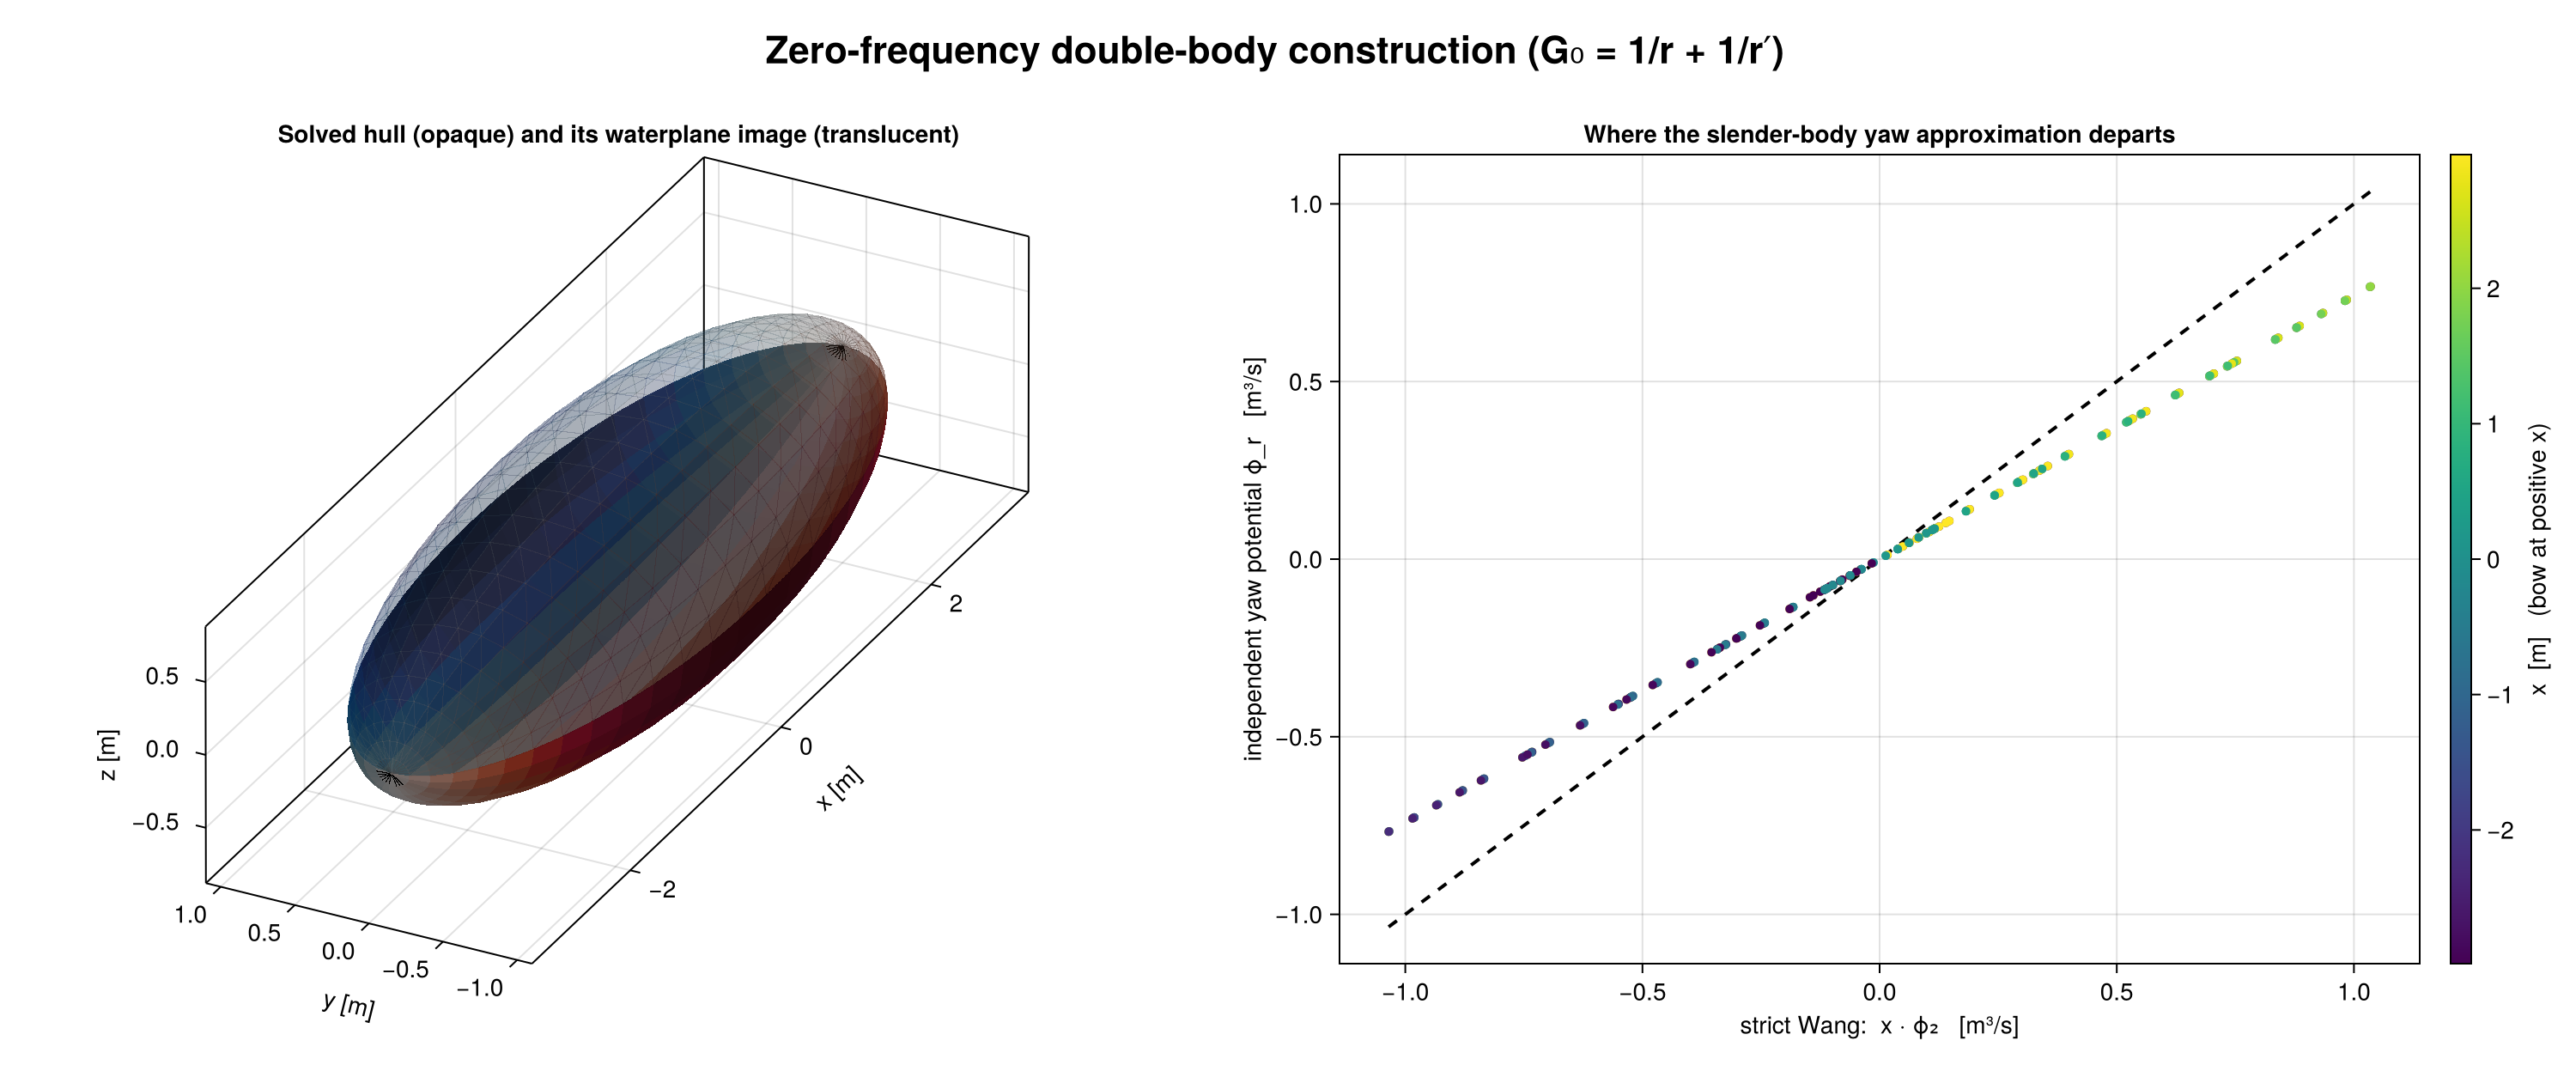

In [3]:
semi_axes = (3.0, 1.0, 0.8)
density = 1000.0
forward_speed = 1.0

double_body_mesh = surface_piercing_ellipsoid_mesh(
    semi_axes; longitudinal_panels=28, girth_panels=14,
)
double_body = solve_potential_flow_maneuvering(
    double_body_mesh, forward_speed; rho=density,
)

"""
Build a triangle soup from a quadrilateral panel mesh, duplicating vertices so
that each panel can carry its own scalar colour. `mirror=true` reflects the
surface in the waterplane, which is what the reflected-Rankine kernel adds.
"""
function panel_triangles(mesh, panel_values; mirror=false)
    points = Point3f[]
    triangles = Vector{NTuple{3,Int}}()
    colors = Float64[]
    for panel in 1:mesh.nfaces
        indices = mesh.faces[panel, :] .+ 1
        base = length(points)
        for index in indices
            z = mesh.vertices[index, 3]
            push!(points, Point3f(mesh.vertices[index, 1],
                                  mesh.vertices[index, 2],
                                  mirror ? -z : z))
            push!(colors, panel_values[panel])
        end
        push!(triangles, (base + 1, base + 2, base + 3))
        push!(triangles, (base + 1, base + 3, base + 4))
    end
    face_matrix = reduce(vcat, [[t[1] t[2] t[3]] for t in triangles])
    return points, face_matrix, colors
end

sway_potential = double_body.potentials.sway
color_range = maximum(abs, sway_potential) .* (-1, 1)
body_points, body_faces, body_colors =
    panel_triangles(double_body_mesh, sway_potential)
image_points, image_faces, image_colors =
    panel_triangles(double_body_mesh, sway_potential; mirror=true)

figure = Figure(size=(1500, 620), backgroundcolor=:white)
axis = Axis3(figure[1, 1]; aspect=:data, azimuth=1.15pi, elevation=0.16pi,
    xlabel="x [m]", ylabel="y [m]", zlabel="z [m]",
    title="Solved hull (opaque) and its waterplane image (translucent)")
mesh!(axis, body_points, body_faces; color=body_colors, colormap=:balance,
    colorrange=color_range)
mesh!(axis, image_points, image_faces; color=image_colors, colormap=:balance,
    colorrange=color_range, alpha=0.22, transparency=true)

yaw_potential = double_body.potentials.yaw
strict_yaw = double_body_mesh.centers[:, 1] .* sway_potential

comparison_axis = Axis(figure[1, 2];
    xlabel="strict Wang:  x · ϕ₂   [m³/s]",
    ylabel="independent yaw potential ϕ_r   [m³/s]",
    title="Where the slender-body yaw approximation departs")
limit = maximum(abs, vcat(strict_yaw, yaw_potential))
lines!(comparison_axis, [-limit, limit], [-limit, limit];
    color=:black, linestyle=:dash, linewidth=2)
scatter!(comparison_axis, strict_yaw, yaw_potential;
    color=double_body_mesh.centers[:, 1], colormap=:viridis, markersize=7)
Colorbar(figure[1, 3]; limits=extrema(double_body_mesh.centers[:, 1]),
    colormap=:viridis, label="x  [m]   (bow at positive x)")

Label(figure[0, :], "Zero-frequency double-body construction (G₀ = 1/r + 1/r′)";
    fontsize=22, font=:bold)
save(joinpath(results_directory, "double_body_construction.png"), figure; px_per_unit=1.5)
figure

## 1.5 Force extraction, and verification of the acceleration derivatives

The pressure comes from the linearized Bernoulli equation in the ship-fixed
frame,

$$p = -\rho\left(\frac{\partial\Phi}{\partial t} - U\frac{\partial\Phi}{\partial x}\right),$$

and the generalized force is $Q = -\oint_{S_h} p\,g_Q\,\mathrm{d}S$ with
$g_Y = n_y$ and $g_N = -(y-y_0)n_x + (x-x_0)n_y$ (the minus sign is because
$\boldsymbol{n}$ points into the fluid). Substituting
$\Phi = U\phi_1 + v\phi_v + r\phi_r$ and collecting terms gives exactly Wang's
equations (13)–(14):

$$\boxed{\;Q_{\dot\jmath} = \rho\int_{S_h}\phi_j\,g_Q\,\mathrm{d}S,
\qquad
Q_j = -\rho U\int_{S_h^{*}}\frac{\partial\phi_j}{\partial x}\,g_Q\,\mathrm{d}S\;}$$

and, in the strict-Wang form where $\phi_r \to x\phi_2$,

$$Y_{\dot v} = \rho\!\int\!\phi_2 n_y\,\mathrm{d}S,\quad
Y_v = -\rho U\!\!\int_{S_h^*}\!\!\phi_{2,x} n_y\,\mathrm{d}S,\quad
Y_{\dot r} = N_{\dot v} = \rho\!\int\! x\phi_2 n_y\,\mathrm{d}S,\quad
N_{\dot r} = \rho\!\int\! x^2\phi_2 n_y\,\mathrm{d}S,$$

$$Y_r = -\rho U\!\!\int_{S_h^*}\!\!(\phi_2 + x\phi_{2,x})n_y\,\mathrm{d}S,\quad
N_v = -\rho U\!\!\int_{S_h^*}\!\! x\phi_{2,x}n_y\,\mathrm{d}S,\quad
N_r = -\rho U\!\!\int_{S_h^*}\!\! x(\phi_2 + x\phi_{2,x})n_y\,\mathrm{d}S.$$

$S_h$ is the whole wetted hull; $S_h^{*}$ is the **Schmitz truncation** — see
§1.7. Wang's normalization, implemented by
`nondimensionalize_maneuvering_derivatives`, is

$$Y_{\dot v}' = \frac{Y_{\dot v}}{\tfrac12\rho L^3},\quad
Y_v' = \frac{Y_v}{\tfrac12\rho L^2 U},\quad
Y_{\dot r}' = \frac{Y_{\dot r}}{\tfrac12\rho L^4},\quad
Y_r' = \frac{Y_r}{\tfrac12\rho L^3 U},$$

with the moment scales carrying one extra power of $L$ each.

### Sign check

The sway added mass is $A_{22} = -Y_{\dot v}$. Since
$\partial\phi_2/\partial n = n_y$, the divergence theorem gives
$\int_{S_h}\phi_2 n_y\,\mathrm{d}S = -\int_V|\nabla\phi_2|^2\,\mathrm{d}V < 0$,
so $A_{22}>0$ as it must be. That is the first consistency check the
implementation has to pass.

### Analytical reference

For an ellipsoid with semi-axes $(a,b,c)$ the classical potential coefficients
are

$$\alpha_i = abc\int_0^\infty\frac{\mathrm{d}\lambda}
{(a_i^2+\lambda)\sqrt{(a^2+\lambda)(b^2+\lambda)(c^2+\lambda)}},
\qquad
m_i = \rho\,\frac{4\pi abc}{3}\,\frac{\alpha_i}{2-\alpha_i},$$

implemented as `ellipsoid_potential_coefficients` and `ellipsoid_added_mass`.
The waterplane is a symmetry plane of the ellipsoid, so the surface-piercing
**lower half solved against a rigid free surface is exactly the full ellipsoid
in unbounded fluid**, and every surface integral is one half of the
corresponding full-body value. The target is therefore $Y_{\dot v} = -m_y/2$.

In [4]:
shapes = [(8, 4), (12, 6), (16, 8), (20, 10), (24, 12), (32, 16)]

coefficients = ellipsoid_potential_coefficients(semi_axes)
analytical_full = ellipsoid_added_mass(semi_axes; density=density)
analytical_sway = analytical_full.y / 2
analytical_volume = 2pi * prod(semi_axes) / 3

mesh_rows = map(shapes) do shape
    mesh = surface_piercing_ellipsoid_mesh(
        semi_axes; longitudinal_panels=shape[1], girth_panels=shape[2],
    )
    result = solve_wang_maneuvering(mesh, forward_speed; rho=density)
    volume = mesh_signed_volume(mesh)
    added_mass = -result.derivatives.Y_vdot
    (; shape, panels=mesh.nfaces,
       volume_relative_error=volume / analytical_volume - 1,
       added_mass, added_mass_relative_error=added_mass / analytical_sway - 1,
       reciprocity_error=result.derivatives.N_vdot - result.derivatives.Y_rdot)
end

println("α = $(coefficients),  Σα = $(sum(coefficients))  (must be 2)")
println("analytical half-body sway added mass = $(analytical_sway) kg")
for row in mesh_rows
    println(row)
end

α = (x = 0.18851757567750904, y = 0.7985064251262597, z = 1.0129759991962266),  Σα = 1.9999999999999953  (must be 2)
analytical half-body sway added mass = 3340.6180060973156 kg
(shape = (8, 4), panels = 32, volume_relative_error = -0.1339499332796914, added_mass = 3603.6278525273146, added_mass_relative_error = 0.07873089528642652, reciprocity_error = 0.0)
(shape = (12, 6), panels = 72, volume_relative_error = -0.06133956098222815, added_mass = 3602.9552183778637, added_mass_relative_error = 0.07852954507271659, reciprocity_error = 0.0)
(shape = (16, 8), panels = 128, volume_relative_error = -0.034866969125615044, added_mass = 3567.493282550017, added_mass_relative_error = 0.0679141631993263, reciprocity_error = 0.0)
(shape = (20, 10), panels = 200, volume_relative_error = -0.02242342580127843, added_mass = 3535.7070239627906, added_mass_relative_error = 0.05839907990359783, reciprocity_error = 0.0)
(shape = (24, 12), panels = 288, volume_relative_error = -0.015612943696948434, added_

$\sum_i\alpha_i = 2$ is an identity of the ellipsoid coefficients and confirms
the quadrature. `reciprocity_error` is exactly zero for the strict-Wang form
because $Y_{\dot r}$ and $N_{\dot v}$ are the same discrete sum
$\rho\sum x\phi_2 n_y\,\Delta S$; for the independent-yaw form it is a genuine
convergence indicator (Green reciprocity holds only in the continuum limit).

The added-mass error is large and stubborn: still 4 % at 512 panels, and only
first order. That is worth chasing down, because it is not the mesh.

### Independent cross-check: the low-frequency limit of the radiation solver

MarineHydro's ordinary radiation calculation shares no code path with the
maneuvering extraction — it uses the Wu wave Green function, a complex solve,
and the **direct** (double-layer) boundary-element formulation. Its sway added
mass must approach the same limit as $\omega\to0$, with the damping vanishing.

In [5]:
frequencies = [0.2, 0.1, 0.05, 0.02, 0.01]
radiation_shape = (16, 8)
radiation_mesh = surface_piercing_ellipsoid_mesh(
    semi_axes; longitudinal_panels=radiation_shape[1],
    girth_panels=radiation_shape[2],
)
wang_zero_frequency = -solve_wang_maneuvering(
    radiation_mesh, forward_speed; rho=density,
).derivatives.Y_vdot

previous_density = SETTINGS.rho
radiation_rows = try
    set_rho!(density)
    map(frequencies) do omega
        added_mass, damping = calculate_radiation_forces(
            radiation_mesh, [0.0, 1.0, 0.0], omega,
        )
        (; omega, added_mass, damping,
           analytical_relative_error=added_mass / analytical_sway - 1,
           wang_relative_difference=added_mass / wang_zero_frequency - 1)
    end
finally
    set_rho!(previous_density)
end
for row in radiation_rows
    println(row)
end

(omega = 0.2, added_mass = 3329.287021869014, damping = 0.00022768660725630403, analytical_relative_error = -0.003391882641960331, wang_relative_difference = -0.06677132703967836)
(omega = 0.1, added_mass = 3323.6498696250023, damping = 1.7816628177606126e-6, analytical_relative_error = -0.0050793405415833215, wang_relative_difference = -0.06835147079820625)
(omega = 0.05, added_mass = 3322.251642459801, damping = 1.3924838200029054e-8, analytical_relative_error = -0.00549789398368572, wang_relative_difference = -0.06874340627066822)
(omega = 0.02, added_mass = 3321.8609289665583, damping = 2.2817023838357163e-11, analytical_relative_error = -0.0056148524304550085, wang_relative_difference = -0.06885292672727406)
(omega = 0.01, added_mass = 3321.805142291842, damping = 1.7826161210786422e-13, analytical_relative_error = -0.005631551937736123, wang_relative_difference = -0.0688685642268565)


The radiation solver converges to $-0.56\,\%$ on the same $16\times8$ mesh
where the Wang path is $+6.8\,\%$ off, and the damping falls to roundoff as
$\omega\to0$ exactly as it should. A factor of twelve in accuracy on identical
geometry is not a mesh effect. It is the **boundary-element formulation**.

### Direct versus indirect

MarineHydro implements both. Writing $\mathbf{S}$ for the single-layer operator
and $\mathbf{D}$, $\mathbf{K}$ for the double-layer operator differentiated at
the field and source point respectively:

| | Unknown | System | Surface potential |
|---|---|---|---|
| **Direct** | $\phi$ on the panels | $\mathbf{D}\boldsymbol{\phi} = \mathbf{S}\boldsymbol{g}$ | solved for directly |
| **Indirect** | source strength $\sigma$ | $\mathbf{K}\boldsymbol{\sigma} = \boldsymbol{g}$ | $\boldsymbol{\phi} = \mathbf{S}\boldsymbol{\sigma}$ |

The velocity derivatives need $\partial\phi/\partial x$ on the hull, and the
indirect formulation hands that over cleanly through the source strengths
(`evaluate_indirect_potential_gradient`), whereas the direct formulation would
require differentiating $\phi$ along the surface. But the acceleration
derivatives need only $\phi$ itself, and there the choice costs an order of
magnitude — so `solve_potential_flow_maneuvering` takes them from a direct
solve of the same right-hand sides. That is the
`acceleration_formulation = :direct` default; pass `:indirect` to reproduce
results from before it was introduced.

In [6]:
formulation_shapes = [(8, 4), (12, 6), (16, 8), (20, 10), (24, 12), (32, 16)]
green_functions = (Rankine(), RankineReflected())

formulation_rows = map(formulation_shapes) do shape
    mesh = surface_piercing_ellipsoid_mesh(
        semi_axes; longitudinal_panels=shape[1], girth_panels=shape[2],
    )
    boundary_condition = maneuvering_boundary_condition(mesh, :sway)
    wavenumber = 0.0
    weight = mesh.normals[:, 2] .* mesh.areas

    S, K = assemble_matrices(green_functions, mesh, wavenumber; direct=false)
    indirect_potential, _ = solve(K, S, boundary_condition; direct=false)

    S_direct, D = assemble_matrices(green_functions, mesh, wavenumber; direct=true)
    direct_potential, _ = solve(D, S_direct, boundary_condition; direct=true)

    indirect = -density * sum(real.(indirect_potential) .* weight)
    direct = -density * sum(real.(direct_potential) .* weight)
    (; panels=mesh.nfaces,
       indirect, direct,
       indirect_error=indirect / analytical_sway - 1,
       direct_error=direct / analytical_sway - 1)
end

for row in formulation_rows
    println((row.panels,
             indirect_percent=100 * row.indirect_error,
             direct_percent=100 * row.direct_error))
end

(panels = 32, indirect_percent = 7.873089528642652, direct_percent = -2.2980577406372826)
(panels = 72, indirect_percent = 7.852954507271659, direct_percent = -0.9809949093260828)
(panels = 128, indirect_percent = 6.7914163199326305, direct_percent = -0.563711848975601)
(panels = 200, indirect_percent = 5.839907990359783, direct_percent = -0.3884502843263693)
(panels = 288, indirect_percent = 5.09496488356882, direct_percent = -0.2906765626317753)
(panels = 512, indirect_percent = 4.016498682904102, direct_percent = -0.1752472933990501)


On identical meshes, with the identical Green function and boundary condition,
the direct formulation is accurate to $0.18\,\%$ at 512 panels where the
indirect one is still at $4\,\%$ — and it reaches the indirect formulation's
best accuracy with 32 panels. The zero-frequency direct value also matches the
radiation solver's $\omega\to0$ limit to five digits, confirming that the two
are the same calculation.

The mesh-convergence table above used `solve_wang_maneuvering`, which stays
on the indirect path to reproduce the paper. The same sequence through
`solve_potential_flow_maneuvering` picks up the direct default:

## 1.6 Verification of the velocity derivatives: the Munk moment

The acceleration derivatives are added masses and are easy to check. The
velocity derivatives are the ones that decide course stability, and they have
never been checked here against an independent result. There is one available.

For a body moving steadily with velocity $(u,v)$ in unbounded ideal fluid with
no circulation, the Kirchhoff equations give the force and moment *exactly*:

$$Y = 0, \qquad N = (A_{11} - A_{22})\,u\,v
\qquad\Longrightarrow\qquad
\boxed{Y_v = 0,\quad N_v = (A_{11}-A_{22})\,U}$$

$N_v$ is the **Munk moment**: because $A_{22}\gg A_{11}$ for a ship-like body
it is negative and destabilizing — the classical reason bare hulls are
directionally unstable. $Y_v=0$ is d'Alembert's paradox: ideal flow produces no
lateral damping at all. Both follow only from the added masses, so they are an
independent target for the whole velocity-derivative pipeline.

The half-ellipsoid double body gives us the full ellipsoid, whose $A_{11}$ and
$A_{22}$ are analytic — so we can compute the target with no BEM at all.

In [7]:
V_ellipsoid = 4pi * prod(semi_axes) / 3
A11 = density * V_ellipsoid * coefficients[1] / (2 - coefficients[1])
A22 = density * V_ellipsoid * coefficients[2] / (2 - coefficients[2])
munk_half_body = (A11 - A22) * forward_speed / 2   # half surface ⇒ half the moment

println("A₁₁ = $(A11) kg,  A₂₂ = $(A22) kg")
println("exact Munk moment N_v (half body) = $(munk_half_body) N·m/(m/s)")

A₁₁ = 1046.2068818228142 kg,  A₂₂ = 6681.236012194631 kg
exact Munk moment N_v (half body) = -2817.5145651859084 N·m/(m/s)


### What the implemented formula actually linearizes

Write the steady base flow in the ship frame as
$\Phi_0 = -Ux + U\phi_1$ — a uniform stream **plus the body's own disturbance**.
Perturbing by a small drift $v$ changes the total potential by
$\delta\Phi = v(-y + \phi_v)$, and the linearized steady Bernoulli pressure is

$$\frac{\partial p}{\partial v} = -\rho\,\nabla\Phi_0\cdot\nabla\!\left(\frac{\partial\Phi}{\partial v}\right)
= \rho U\Big(\underbrace{\phi_{v,x}}_{\text{kept}}
+ \underbrace{\phi_{1,y} - \nabla\phi_1\!\cdot\!\nabla\phi_v}_{\text{dropped by Wang}}\Big).$$

Wang's $p = -\rho(\partial_t - U\partial_x)\Phi$ retains only the first term:
it linearizes about the **undisturbed uniform stream**, not about the actual
double-body base flow. The dropped terms are first order in $v$ and $O(U)$ —
the same order as the term that is kept. They are the "$m$-terms" of
steady-forward-speed seakeeping theory.

Working instead in the body frame, where the quasi-steady flow is stationary,
gives the general form for either mode. With $\boldsymbol{u}_j$ the rigid-body
velocity field of mode $j$ ($\boldsymbol{e}_y$ for sway,
$\boldsymbol{e}_z\times(\boldsymbol{x}-\boldsymbol{x}_0)$ for yaw),

$$\frac{\partial p}{\partial v_j} = \rho U\left(
\frac{\partial\phi_j}{\partial x}
+ \boldsymbol{u}_j\!\cdot\!\nabla\phi_1
- \nabla\phi_1\!\cdot\!\nabla\phi_j\right),$$

which is `steady_pressure_derivative`. Note that the rotation field is not a
gradient, so the yaw case cannot be written as $\nabla\Phi_0\cdot\nabla\delta\Phi$;
the body-frame derivation handles both modes correctly. Setting
$\nabla\phi_1\equiv0$ recovers Wang's term exactly.

`solve_potential_flow_maneuvering` selects between them with `base_flow`,
defaulting to `:double_body`. It costs one extra unit-surge solve — which
notebook 2 needs anyway for the boundary layer.

In [8]:
munk_shapes = [(12, 6), (16, 8), (24, 12), (32, 16), (40, 20)]

munk_rows = map(munk_shapes) do shape
    mesh = surface_piercing_ellipsoid_mesh(
        semi_axes; longitudinal_panels=shape[1], girth_panels=shape[2],
    )
    complete = solve_potential_flow_maneuvering(mesh, forward_speed; rho=density)
    wang = solve_potential_flow_maneuvering(
        mesh, forward_speed; rho=density,
        base_flow=:uniform_stream,
        acceleration_formulation=:indirect,
    )
    (; shape, panels=mesh.nfaces,
       N_v_wang=wang.derivatives.N_v,
       N_v_complete=complete.derivatives.N_v,
       Y_v_wang=wang.derivatives.Y_v,
       Y_v_complete=complete.derivatives.Y_v,
       added_mass_wang=-wang.derivatives.Y_vdot,
       added_mass_complete=-complete.derivatives.Y_vdot)
end

for row in munk_rows
    println((row.shape, row.panels,
             wang_over_munk=row.N_v_wang / munk_half_body,
             complete_over_munk=row.N_v_complete / munk_half_body,
             Y_v_wang=row.Y_v_wang, Y_v_complete=row.Y_v_complete))
end

(shape = (12, 6), panels = 72, wang_over_munk = 0.8839354836342652, complete_over_munk = 0.9676040350130447, Y_v_wang = 1.0278236595162582e-13, Y_v_complete = -1.0746958878371515e-13)
(shape = (16, 8), panels = 128, wang_over_munk = 0.8982146803854656, complete_over_munk = 0.9847039322656166, Y_v_wang = 7.19910242530375e-14, Y_v_complete = 1.9506618542664e-13)
(shape = (24, 12), panels = 288, wang_over_munk = 0.9057972414107281, complete_over_munk = 0.9950781013048003, Y_v_wang = 1.2563192673675783e-13, Y_v_complete = 1.396660564978447e-13)
(shape = (32, 16), panels = 512, wang_over_munk = 0.9074605576337504, complete_over_munk = 0.99791245617428, Y_v_wang = 8.98769719672593e-14, Y_v_complete = 5.857814233678482e-14)
(shape = (40, 20), panels = 800, wang_over_munk = 0.908006934040937, complete_over_munk = 0.9992130453020625, Y_v_wang = -1.994898116055438e-13, Y_v_complete = -2.869319365439438e-13)


The result is unambiguous:

* $Y_v$ is zero to roundoff in **both** forms — d'Alembert is satisfied, and
  the ideal-flow model produces no sway damping whatsoever. Every bit of $Y_v$
  reported for a real hull therefore comes from the Schmitz truncation (§1.7)
  or the viscous correction (notebook 2), never from the potential flow itself.
* The **complete** linearization converges cleanly to the exact Munk moment,
  reaching $0.9992$ at 800 panels.
* Wang's form converges to a *different* value, about 9 % low for this
  ellipsoid, and refining the mesh does not remove the gap. It is a modeling
  error, not a discretization error.

For a full hull the gap is larger, because the disturbance $U\nabla\phi_1$ is a
bigger fraction of the total base flow: on KVLCC2 (notebook 2) the two forms
differ by roughly 16 %.

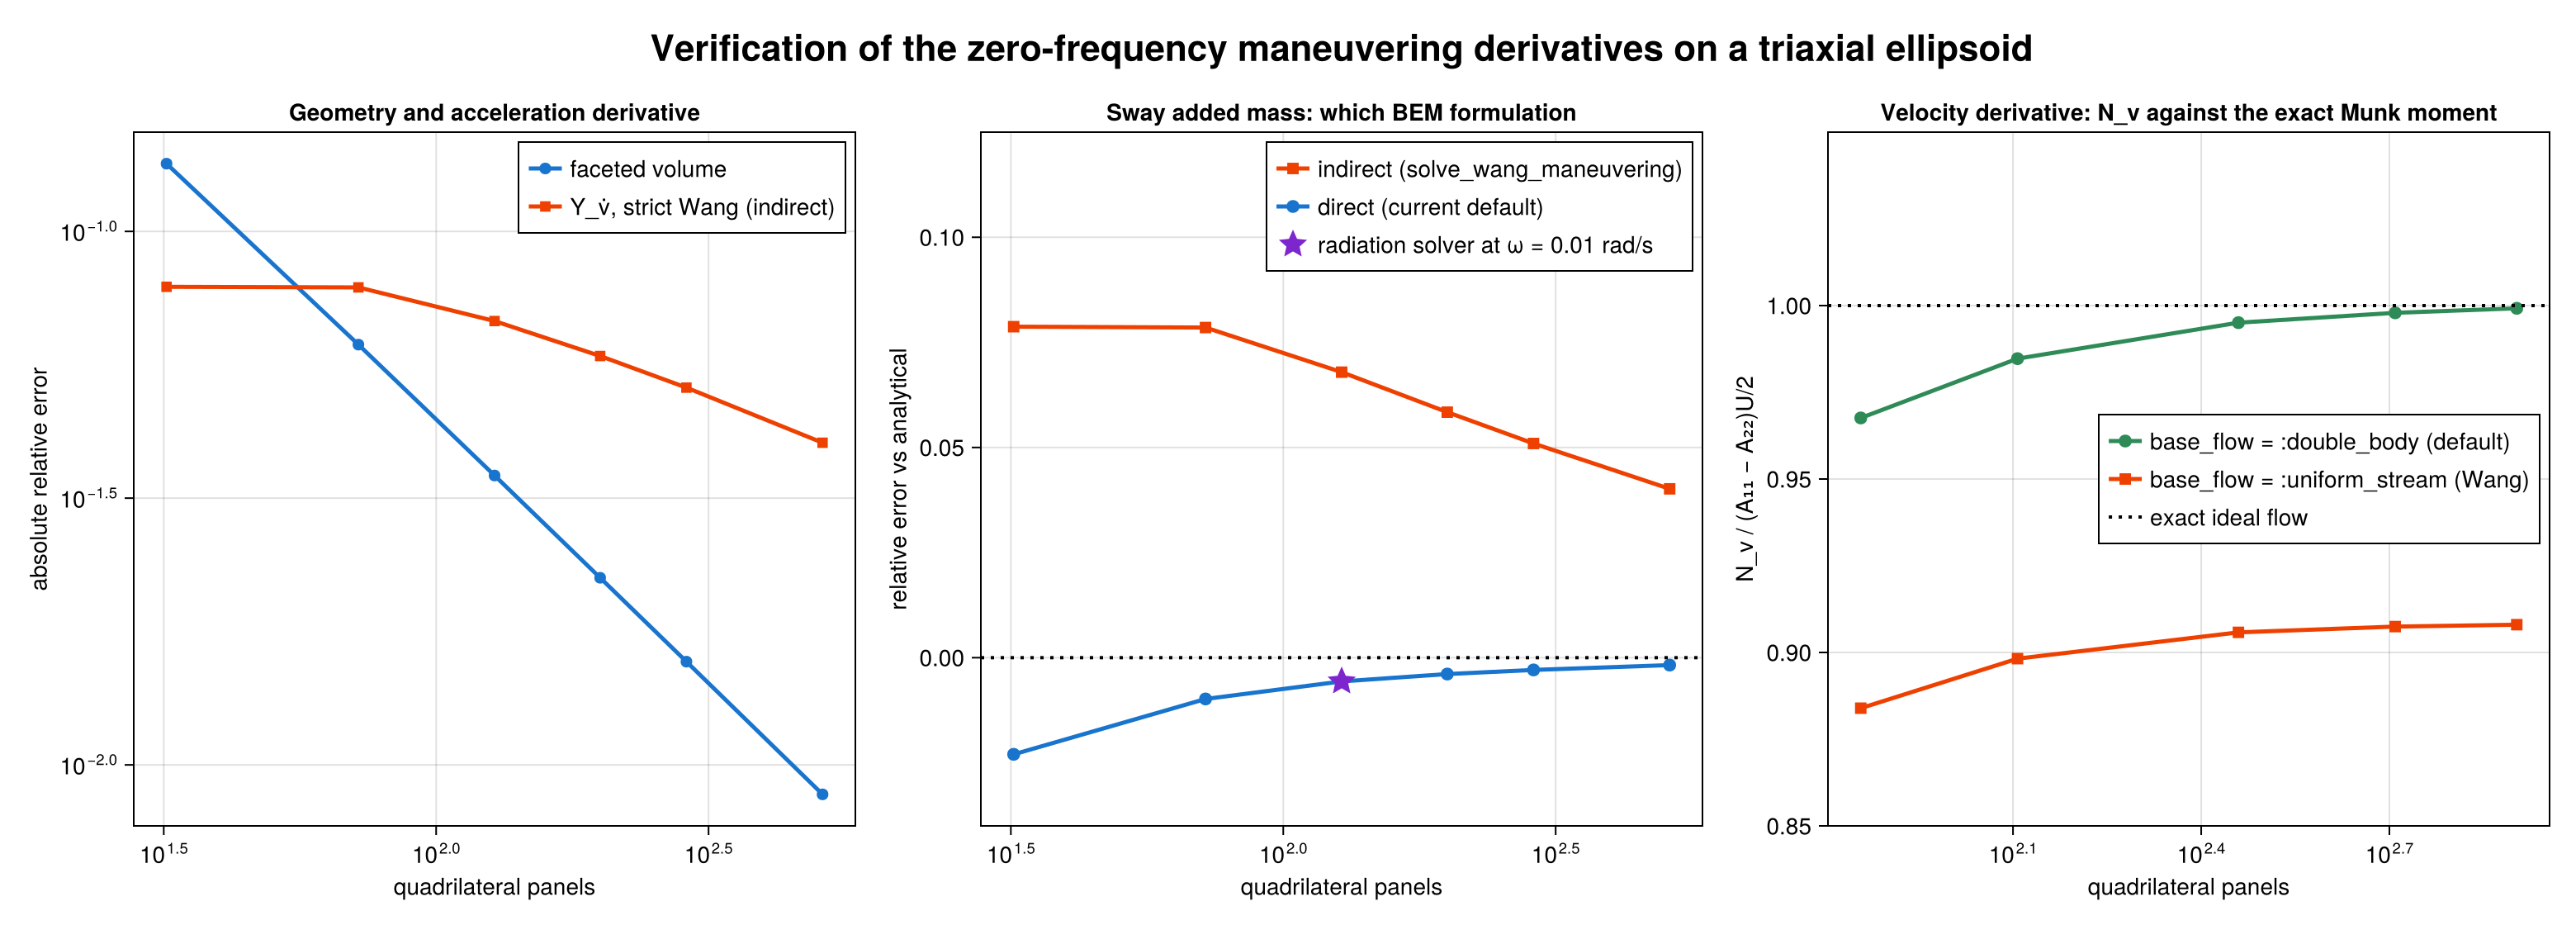

In [9]:
figure = Figure(size=(1560, 560), backgroundcolor=:white)

convergence_axis = Axis(figure[1, 1];
    title="Geometry and acceleration derivative",
    xlabel="quadrilateral panels", ylabel="absolute relative error",
    xscale=log10, yscale=log10)
panels = [row.panels for row in mesh_rows]
scatterlines!(convergence_axis, panels,
    abs.([row.volume_relative_error for row in mesh_rows]);
    color=:dodgerblue3, linewidth=2.5, marker=:circle, markersize=10,
    label="faceted volume")
scatterlines!(convergence_axis, panels,
    abs.([row.added_mass_relative_error for row in mesh_rows]);
    color=:orangered2, linewidth=2.5, marker=:rect, markersize=10,
    label="Y_v̇, strict Wang (indirect)")
axislegend(convergence_axis; position=:rt)

formulation_axis = Axis(figure[1, 2];
    title="Sway added mass: which BEM formulation",
    xlabel="quadrilateral panels", ylabel="relative error vs analytical",
    xscale=log10)
formulation_panels = [row.panels for row in formulation_rows]
scatterlines!(formulation_axis, formulation_panels,
    [row.indirect_error for row in formulation_rows];
    color=:orangered2, linewidth=2.5, marker=:rect, markersize=11,
    label="indirect (solve_wang_maneuvering)")
scatterlines!(formulation_axis, formulation_panels,
    [row.direct_error for row in formulation_rows];
    color=:dodgerblue3, linewidth=2.5, marker=:circle, markersize=11,
    label="direct (current default)")
scatter!(formulation_axis, [radiation_mesh.nfaces],
    [last(radiation_rows).analytical_relative_error];
    color=:purple3, marker=:star5, markersize=20,
    label="radiation solver at ω = 0.01 rad/s")
hlines!(formulation_axis, [0.0]; color=:black, linewidth=2, linestyle=:dot)
ylims!(formulation_axis, -0.04, 0.125)
axislegend(formulation_axis; position=:rt)

munk_axis = Axis(figure[1, 3];
    title="Velocity derivative: N_v against the exact Munk moment",
    xlabel="quadrilateral panels", ylabel="N_v / (A₁₁ − A₂₂)U/2",
    xscale=log10)
munk_panels = [row.panels for row in munk_rows]
scatterlines!(munk_axis, munk_panels,
    [row.N_v_complete / munk_half_body for row in munk_rows];
    color=:seagreen4, linewidth=2.5, marker=:circle, markersize=11,
    label="base_flow = :double_body (default)")
scatterlines!(munk_axis, munk_panels,
    [row.N_v_wang / munk_half_body for row in munk_rows];
    color=:orangered2, linewidth=2.5, marker=:rect, markersize=11,
    label="base_flow = :uniform_stream (Wang)")
hlines!(munk_axis, [1.0]; color=:black, linewidth=2, linestyle=:dot,
    label="exact ideal flow")
ylims!(munk_axis, 0.85, 1.05)
axislegend(munk_axis; position=:rc)

Label(figure[0, :],
    "Verification of the zero-frequency maneuvering derivatives on a triaxial ellipsoid";
    fontsize=22, font=:bold)
save(joinpath(results_directory, "ellipsoid_verification.png"), figure; px_per_unit=1.5)
figure

## 1.7 The Schmitz stern truncation

Since ideal flow gives $Y_v = 0$, Wang et al. recover a lateral force with a
semi-empirical device taken from Schmitz. A hull at drift sheds vorticity from
the after body; those trailing vortices unload the stern pressures while
leaving the bow largely unaffected. The velocity-derivative integrals are
therefore truncated: they run from the forward perpendicular aft only as far as
$S_h^{*}$, the section of maximum cross-sectional area, and the remainder of
the hull is discarded.

`wang_stern_mask(mesh, x_cut)` builds that mask (keeping $x \ge x_{cut}$ with
the bow at positive $x$), and every derivative function accepts it through
`velocity_mask`. The acceleration integrals always use the complete hull.
`gothenburg_maximum_section` derives $x_{cut}$ automatically from the sectional
area curve of a structured hull surface.

Two limitations to record:

1. **The truncation is the entire model for $Y_v$.** The magnitude of $Y_v$ is
   set by where the cut is placed, and the cut is a fitted quantity. This is a
   calibration, not a prediction.
2. **Wang uses two different cuts.** The paper places the cut at the maximum-area
   section for $Y_v'$ and $N_v'$ but explicitly *further aft* for $Y_r'$ and
   $N_r'$, and recommends obtaining those two from Clarke's regressions instead,

   $$Y_r' = \left(-\tfrac12 + 1.73\tfrac{B}{L}\right)Y_v', \qquad
   N_r' = 0.08\,Y_v' + \tfrac14\left(1-0.938\,C_B\tfrac{B}{L}\right)
   \left(-\left(\tfrac{T}{L}\right)^2\right).$$

   `clarke_rotational_derivatives` implements both, and
   `rotational_velocity_mask` allows the two coefficient pairs to be truncated
   at different stations. Applying one mask to all four is what produces the
   wrong-sign $Y_r'$ seen in notebook 2.

In [10]:
# KVLCC2: B = 58 m, L = 320 m, T = 20.8 m, C_B = 0.81. Y_v' is the
# model-test value in Wang's normalization.
clarke = clarke_rotational_derivatives(-0.020475, 58.0, 320.0, 20.8, 0.81)
(; clarke_Y_r=clarke.Y_r, reference_Y_r=0.005395,
   clarke_N_r=clarke.N_r, reference_N_r=-0.003185)

(clarke_Y_r = 0.0038173078125000007, reference_Y_r = 0.005395, clarke_N_r = -0.00254879368046875, reference_N_r = -0.003185)

Clarke's regressions get both signs right and land within 30 % of the
model-test values — considerably better than direct truncated integration,
which produces the wrong sign for $Y_r'$ entirely.

## 1.8 Summary of what is and is not verified

| Quantity | Status |
|---|---|
| Free-surface condition at $\omega\to0$ | Exact by construction (reflected Rankine) |
| Hull boundary conditions, all three modes | Verified against definitions |
| $Y_{\dot v}$, $N_{\dot r}$ (added mass) | Verified against the analytic ellipsoid and the radiation solver's $\omega\to0$ limit. Within $0.18\,\%$ at 512 panels on the `:direct` default; $4\,\%$ on `:indirect` |
| $Y_{\dot r} = N_{\dot v}$ reciprocity | Exact for strict Wang; convergent for independent yaw |
| Wang normalization, MMG conversion | Verified against the paper |
| $Y_v = 0$ in ideal flow | Verified to roundoff |
| $N_v$ (Munk moment) | Verified: $0.9992$ of the exact value at 800 panels on the `:double_body` default. Wang's `:uniform_stream` form converges to $0.908$ |
| $Y_r$, $N_r$ for a real hull | **Not verified from first principles.** Either truncate at a separate rotational station or use `clarke_rotational_derivatives` |
| $Y_v$ for a real hull | **Not predictive from potential flow** — it is identically zero, and its whole magnitude comes from the Schmitz cut or the viscous correction |

Notebook 2 takes the KVLCC2 hull through the same pipeline and adds the
viscous correction that is supposed to supply the missing $Y_v$.